In [108]:
import numpy as np
import pandas as pd
from pathlib import Path
import pyarrow.parquet as pq
from sklearn.manifold import TSNE
import scienceplots
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

from bscarlos.settings import PROCESSED_KISPI_DATA_FOLDER

plt.style.use(['science', 'no-latex'])

# Preproccess EEG Data

In [109]:
file_path = PROCESSED_KISPI_DATA_FOLDER / Path("SE021_a1_filt_merged.parquet")

table = pq.read_table(file_path)

df = table.to_pandas()

print(df.head())

     Fp1-F7     F7-T3     T3-T5    Fp2-F8     F8-T4     T4-T6  ground_truth
0  0.124338  0.000000 -0.165783  0.331567  0.306699 -0.099470             0
1  0.248675 -0.132627  0.447615  2.851475  1.632967 -0.886941             0
2  0.314988 -0.215518  1.152195  5.213888  2.851475 -1.657834             0
3  0.223808 -0.165783  2.005979  7.269603  3.837886 -2.378992             0
4 -0.033157  0.041446  3.066993  8.885991  4.525887 -3.025547             0


## Remove Ground Truth Labels

In [110]:
eeg_data = df.drop('ground_truth', axis=1)
eeg_data

,Fp1-F7,F7-T3,T3-T5,Fp2-F8,F8-T4,T4-T6
0,0.124338,0.000000,-0.165783,0.331567,0.306699,-0.099470
1,0.248675,-0.132627,0.447615,2.851475,1.632967,-0.886941
2,0.314988,-0.215518,1.152195,5.213888,2.851475,-1.657834
3,0.223808,-0.165783,2.005979,7.269603,3.837886,-2.378992
4,-0.033157,0.041446,3.066993,8.885991,4.525887,-3.025547
...,...,...,...,...,...,...
368635,7.153554,0.613399,-2.834896,-2.851475,4.103140,5.843864
368636,5.230467,0.447615,-2.138606,-2.453595,3.224487,4.227477
368637,3.249355,0.265253,-1.434026,-1.807039,2.221498,2.611089
368638,1.243376,0.074603,-0.729447,-0.978122,1.135616,0.978122


In [111]:
eeg_data = eeg_data.values

## Normalize

Since VAE uses a sigmoid activation in the decoder, normalize values between 0 and 1

In [112]:
eeg_data_min = eeg_data.min()
print(eeg_data_min)
eeg_data_max = eeg_data.max()
print(eeg_data_max)
eeg_data = (eeg_data - eeg_data_min) / (eeg_data_max - eeg_data_min)

-203.83899
212.71669


## Segment
Segment EEG data into 2-second windows (512 samples at 256Hz)

$$window size=512(samples)×6(channels)=3072(features)$$

In [113]:
window_size = 512
num_windows = eeg_data.shape[0] // window_size
print(num_windows)

720


## Reshape

reshaped_data.shape=(num_windows,3072)

In [114]:
# Reshape EEG data into (num_windows, 3072)
reshaped_data = eeg_data[:num_windows * window_size]  # Trim excess samples
reshaped_data = reshaped_data.reshape(-1, window_size * 6)  # Shape: (num_windows, 3072)
print("Reshaped EEG data shape:", reshaped_data.shape)

Reshaped EEG data shape: (720, 3072)


## Split into Train, Validation, and Test Sets

In [115]:
X_train, X_temp = train_test_split(reshaped_data, test_size=0.2, random_state=42)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (576, 3072)
Validation data shape: (72, 3072)
Test data shape: (72, 3072)


# Hyperparameters

After multiple (see colab notebooks) experiments the optimal hyperparameters are  the following: 

In [116]:
input_dim = 3072  # 512 samples * 7 channels
output_dim = 3072  # Reconstruction matches input
latent_dim = 32 
batch_size = 64 
lr = 1e-5 
num_epochs = 100
beta = 0.8 


## Create Pytorch Dataset

In [117]:
class EEGDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], 0  # Dummy label for VAE

# Create separate datasets for train, validation, and test
train_dataset = EEGDataset(X_train)
val_dataset = EEGDataset(X_val)
test_dataset = EEGDataset(X_test)

# Define batch size
batch_size = batch_size

# Create DataLoaders for each split
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print the number of batches in each DataLoader
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Number of training batches: 9
Number of validation batches: 2
Number of test batches: 2


# Encoder
  The encoder network takes in the data `input_dim`, processes it through a few fully connected layers, and outputs the mean ($mu$) and log-variance (log_var) of the latent distribution. $$input\_dim=512×7=3584$$

In [118]:
# Define the Encoder network
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        # Define a simple feed-forward network for the encoder
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3_mu = nn.Linear(256, latent_dim)  # Mean of the latent variable
        self.fc3_logvar = nn.Linear(256, latent_dim)  # Log variance of the latent variable

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Ensure input is flattened
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        mu = self.fc3_mu(x)
        logvar = self.fc3_logvar(x)
        return mu, logvar

# Decoder

In [119]:
# Define the Decoder network
class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        # Define a simple feed-forward network for the decoder
        self.fc1 = nn.Linear(latent_dim, 256)
        self.fc2 = nn.Linear(256, 512)
        self.fc3 = nn.Linear(512, output_dim)

    def forward(self, z):
        z = z.view(z.size(0), -1)  # Ensure input is flattened
        z = F.relu(self.fc1(z))
        z = F.relu(self.fc2(z))
        reconstruction = torch.sigmoid(self.fc3(z))  # Sigmoid for binary outputs
        return reconstruction

# Reparameterization Trick

In [120]:
# Reparameterization trick
def reparameterize(mu, logvar):
    std = torch.exp(0.5*logvar)
    eps = torch.randn_like(std)
    z = mu + eps*std
    return z

# VAE Model

In [121]:
# VAE Model
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim, output_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, latent_dim)
        self.decoder = Decoder(latent_dim, output_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        reconstructed_x = self.decoder(z)
        return reconstructed_x, mu, logvar, z # Retrun latent variables (z)

    def loss_function(self, recon_x, x, mu, logvar, beta=0.1):
        # Reconstruction loss (binary cross-entropy)
        #BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
        # Reconstruction loss (MSE for continuous data)
        #MSE = F.mse_loss(recon_x, x, reduction='sum')
        # L1 Reconstruction loss (absolute error)
        recon_loss = torch.sum(torch.abs(recon_x - x))

        # KL divergence loss
        # Compute the KL divergence between the learned distribution and the prior (N(0, I))
        # Use the formula: KL(q(z|x) || p(z)) = 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
        # where mu is the mean and logvar is the log variance
        # sigma^2 = exp(logvar)
        # Here we calculate the negative log-likelihood in a variational autoencoder
        # for an isotropic Gaussian distribution
        KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        # The total loss is the sum of the reconstruction loss and KL divergence
        total_loss = recon_loss + beta * KL # + BCA, + MSE
        return total_loss 

# Hyperparameters
input_dim = input_dim
latent_dim = latent_dim
output_dim = output_dim

# Create the VAE model
model = VAE(input_dim=input_dim, latent_dim=latent_dim, output_dim=output_dim)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)


# Train

In [122]:
for epoch in range(num_epochs):
    # Training
    model.train()
    for batch_idx, (data, _) in enumerate(train_loader):
        optimizer.zero_grad()
        recon_batch, mu, logvar, z = model(data)
        loss = model.loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_idx, (data, _) in enumerate(val_loader):
            recon_batch, mu, logvar, z = model(data)
            val_loss += model.loss_function(recon_batch, data, mu, logvar).item()

    val_loss /= len(val_loader.dataset)
    print(f"Epoch {epoch+1}, Validation Loss: {val_loss:.4f}")


Epoch 1, Validation Loss: 121.0182
Epoch 2, Validation Loss: 118.6929
Epoch 3, Validation Loss: 117.4935
Epoch 4, Validation Loss: 116.2866
Epoch 5, Validation Loss: 114.9975
Epoch 6, Validation Loss: 112.9310
Epoch 7, Validation Loss: 112.5294
Epoch 8, Validation Loss: 112.5095
Epoch 9, Validation Loss: 110.8775
Epoch 10, Validation Loss: 110.7828
Epoch 11, Validation Loss: 109.8499
Epoch 12, Validation Loss: 109.2859
Epoch 13, Validation Loss: 109.1927
Epoch 14, Validation Loss: 108.4435
Epoch 15, Validation Loss: 108.1903
Epoch 16, Validation Loss: 107.7376
Epoch 17, Validation Loss: 107.3720
Epoch 18, Validation Loss: 107.0655
Epoch 19, Validation Loss: 106.9509
Epoch 20, Validation Loss: 106.6766
Epoch 21, Validation Loss: 106.5778
Epoch 22, Validation Loss: 106.2182
Epoch 23, Validation Loss: 106.0804
Epoch 24, Validation Loss: 105.9950
Epoch 25, Validation Loss: 105.9520
Epoch 26, Validation Loss: 105.6569
Epoch 27, Validation Loss: 105.5744
Epoch 28, Validation Loss: 105.4420
E

In [123]:
# Training loop + monitor both loss components
def train(model, train_loader, optimizer, num_epochs=num_epochs):
    model.train()

    # Lists to store the losses
    recon_losses = []
    kl_losses = []
    total_losses = []

    for epoch in range(num_epochs):
        train_recon_loss, train_kl_loss , train_total_loss = 0, 0, 0

        for batch_idx, (data, _) in enumerate(train_loader):
            optimizer.zero_grad()

            # Forward pass
            recon_batch, mu, logvar, z = model(data)

            # Compute the reconstruction loss (L1-norm or MSE)
            recon_loss = torch.sum(torch.abs(recon_batch - data))  # L1 loss, or use MSE
            # Or
            #recon_loss = F.mse_loss(recon_batch, data, reduction='sum')

            # Compute KL divergence
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            # Total loss (sum of both losses)
            total_loss = recon_loss + kl_loss * beta

            # Backpropagation
            total_loss.backward()
            optimizer.step()

            # Accumulate losses for averaging
            train_recon_loss += recon_loss.item()
            train_kl_loss += kl_loss.item()
            train_total_loss += total_loss.item()

        # Average losses for this epoch
        recon_losses.append(train_recon_loss / len(train_loader.dataset))
        kl_losses.append(train_kl_loss / len(train_loader.dataset))
        total_losses.append(train_total_loss / len(train_loader.dataset))

        # Print losses for the current epoch
        print(f"Epoch {epoch+1}/{num_epochs}, "
              f"Recon Loss: {recon_losses[-1]:.4f}, "
              f"KL Loss: {kl_losses[-1]:.4f}, "
              f"Total Loss: {total_losses[-1]:.4f}")

    return recon_losses, kl_losses, total_losses

In [124]:
# Train the model
train(model, train_loader, optimizer)

Epoch 1/100, Recon Loss: 98.3710, KL Loss: 9.2420, Total Loss: 105.7647
Epoch 2/100, Recon Loss: 98.9976, KL Loss: 5.8653, Total Loss: 103.6898
Epoch 3/100, Recon Loss: 99.8195, KL Loss: 3.5146, Total Loss: 102.6312
Epoch 4/100, Recon Loss: 100.2508, KL Loss: 2.3889, Total Loss: 102.1620
Epoch 5/100, Recon Loss: 100.4138, KL Loss: 1.9344, Total Loss: 101.9613
Epoch 6/100, Recon Loss: 100.2471, KL Loss: 1.7487, Total Loss: 101.6461
Epoch 7/100, Recon Loss: 100.2082, KL Loss: 1.6249, Total Loss: 101.5082
Epoch 8/100, Recon Loss: 100.0728, KL Loss: 1.5097, Total Loss: 101.2806
Epoch 9/100, Recon Loss: 100.0541, KL Loss: 1.3976, Total Loss: 101.1722
Epoch 10/100, Recon Loss: 100.0565, KL Loss: 1.2918, Total Loss: 101.0900
Epoch 11/100, Recon Loss: 99.9909, KL Loss: 1.1976, Total Loss: 100.9490
Epoch 12/100, Recon Loss: 99.8926, KL Loss: 1.1097, Total Loss: 100.7804
Epoch 13/100, Recon Loss: 100.0012, KL Loss: 1.0172, Total Loss: 100.8150
Epoch 14/100, Recon Loss: 100.0107, KL Loss: 0.9415,

([98.37103271484375,
  98.99757809109158,
  99.81949361165364,
  100.25083923339844,
  100.41381242540147,
  100.2471457587348,
  100.20824856228299,
  100.07280815972223,
  100.05410766601562,
  100.05650922987196,
  99.99085913764105,
  99.8926289876302,
  100.00120798746745,
  100.01073201497395,
  99.8545388115777,
  99.85167185465495,
  99.88003963894315,
  99.90388827853732,
  99.73613569471571,
  99.81975470648871,
  99.69764709472656,
  99.74146694607205,
  99.68412441677518,
  99.62579091389973,
  99.68505181206598,
  99.66807386610243,
  99.58328586154514,
  99.57611846923828,
  99.46625688340929,
  99.54354265001085,
  99.3993631998698,
  99.47847493489583,
  99.4656490749783,
  99.45939212375217,
  99.38512674967448,
  99.32714250352647,
  99.30491383870442,
  99.30566830105252,
  99.32197909884982,
  99.29376559787326,
  99.26931423611111,
  99.26475185818143,
  99.14191606309679,
  99.1668701171875,
  99.12406836615668,
  99.1647711859809,
  99.09356943766277,
  99.022093

# Plot Latent Space Variables (z)

Interpreting the t-SNE Plot:

If the model is learning well, you should see clusters or groupings of similar samples in the latent space. 

This indicates that similar data points (e.g., EEG segments with similar patterns) are being represented similarly in the latent space.


If the points are scattered randomly, it might indicate that the model is not learning a useful latent representation. In this case, you may need to adjust hyperparameters like the latent dimension or training procedure.

In [125]:
def tsne_latent_space(model, train_loader):
    model.eval()
    all_latents = []
    all_labels = []  # Store labels if available, can be useful for coloring the plot

    with torch.no_grad():  # No need to track gradients during inference
        for data, labels in train_loader:
            recon_batch, mu, logvar, z = model(data)  # Get the latent variable z
            all_latents.append(z.cpu().numpy())  # Move data to CPU and collect
            all_labels.append(labels.cpu().numpy())  # Collect labels (if necessary)

    all_latents = np.concatenate(all_latents, axis=0)  # Concatenate the latent variables
    all_labels = np.concatenate(all_labels, axis=0) 

    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    latent_2d = tsne.fit_transform(all_latents) 

    # Plot the latent space
    plt.figure(figsize=(8, 6))
    plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=all_labels, cmap='jet', alpha=0.5)
    plt.title("Latent Space Visualization with t-SNE")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.colorbar()
    plt.show()


In [126]:
#tsne_latent_space(model, train_loader)

In [127]:
def tsne_latent_space_nolabels(model, train_loader):
    model.eval()  # Set the model to evaluation mode
    all_latents = []

    with torch.no_grad():  # No need to track gradients during inference
        for data, _ in train_loader:  # We don't need labels here
            recon_batch, mu, logvar, z = model(data)  # Get the latent variable z
            all_latents.append(z.cpu().numpy())  # Collect latent variables

    all_latents = np.concatenate(all_latents, axis=0)  # Concatenate the latent variables

    # Apply t-SNE to reduce to 2D for visualization
    tsne = TSNE(n_components=2, random_state=42) #,metric='precomputed', init='random'
    latent_2d = tsne.fit_transform(all_latents)  # Project to 2D space

    # Plot the latent space
    plt.figure(figsize=(8, 6))
    plt.scatter(latent_2d[:, 0], latent_2d[:, 1], alpha=0.5)
    plt.title("Latent Space Visualization with t-SNE")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()


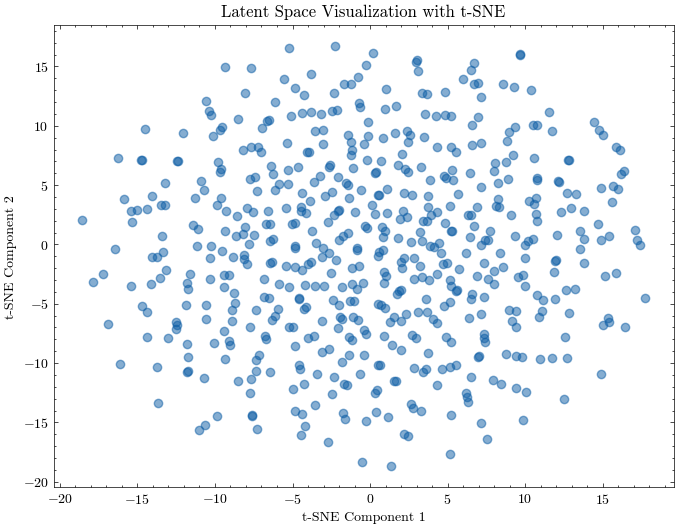

In [128]:
tsne_latent_space_nolabels(model, train_loader)

# Plot Loss Functions

Epoch 1/200, Recon Loss: 97.2110, KL Loss: 0.0101, Total Loss: 97.2191
Epoch 2/200, Recon Loss: 97.2085, KL Loss: 0.0090, Total Loss: 97.2156
Epoch 3/200, Recon Loss: 97.1885, KL Loss: 0.0080, Total Loss: 97.1949
Epoch 4/200, Recon Loss: 97.2163, KL Loss: 0.0080, Total Loss: 97.2227
Epoch 5/200, Recon Loss: 97.1895, KL Loss: 0.0088, Total Loss: 97.1965
Epoch 6/200, Recon Loss: 97.1988, KL Loss: 0.0087, Total Loss: 97.2057
Epoch 7/200, Recon Loss: 97.1933, KL Loss: 0.0088, Total Loss: 97.2003
Epoch 8/200, Recon Loss: 97.1924, KL Loss: 0.0090, Total Loss: 97.1996
Epoch 9/200, Recon Loss: 97.1942, KL Loss: 0.0084, Total Loss: 97.2009
Epoch 10/200, Recon Loss: 97.1884, KL Loss: 0.0082, Total Loss: 97.1950
Epoch 11/200, Recon Loss: 97.1682, KL Loss: 0.0089, Total Loss: 97.1753
Epoch 12/200, Recon Loss: 97.1961, KL Loss: 0.0085, Total Loss: 97.2029
Epoch 13/200, Recon Loss: 97.1592, KL Loss: 0.0077, Total Loss: 97.1653
Epoch 14/200, Recon Loss: 97.1502, KL Loss: 0.0071, Total Loss: 97.1559
E

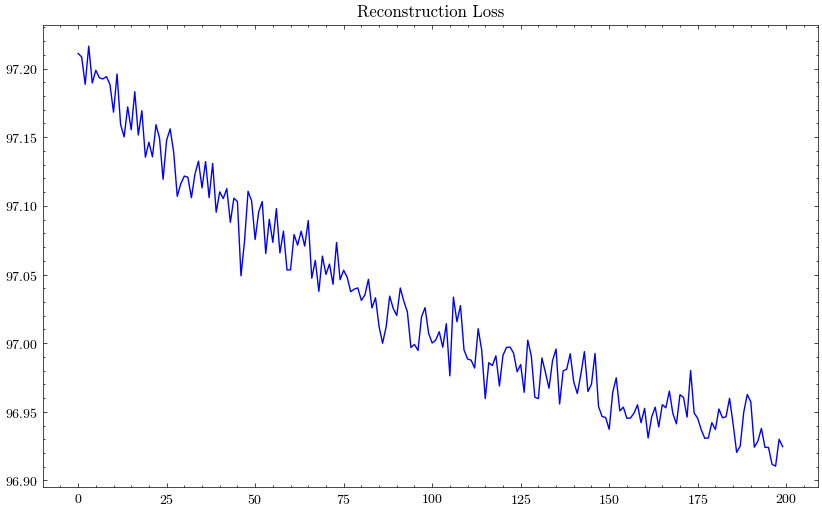

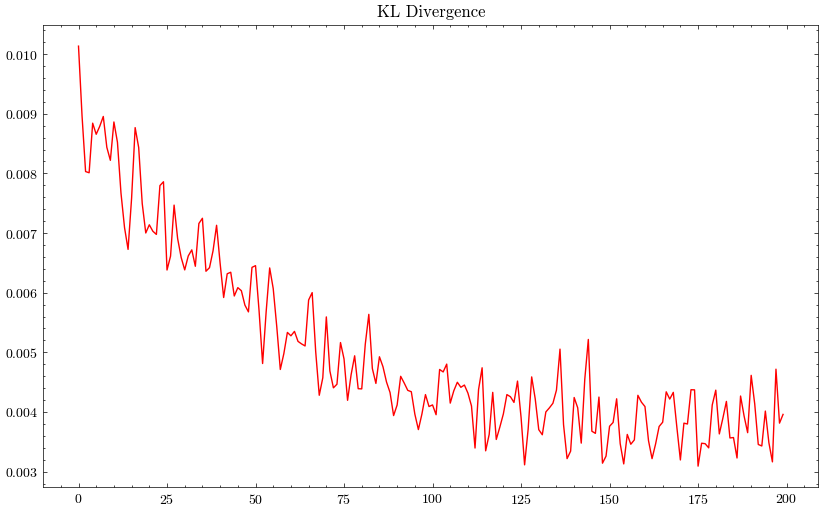

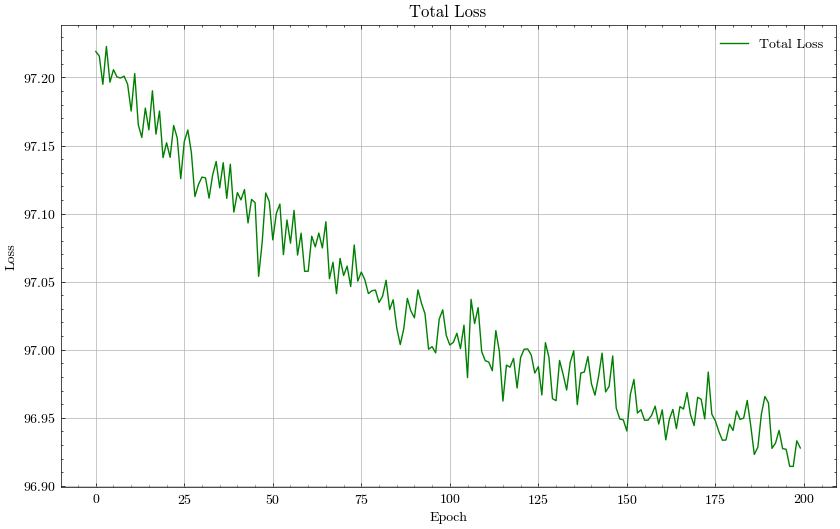

In [ ]:
# Assuming you've trained your model and stored the losses
recon_losses, kl_losses, total_losses = train(model, train_loader, optimizer, num_epochs=200)

# Plot the losses
plt.figure(figsize=(10, 6))
plt.title('Reconstruction Loss')
plt.plot(recon_losses, label='Reconstruction Loss', color='b')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.figure(figsize=(10, 6))
plt.title('KL Divergence')
plt.plot(kl_losses, label='KL Divergence', color='r')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.figure(figsize=(10, 6))
plt.title('Total Loss')
plt.plot(total_losses, label='Total Loss', color='g')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

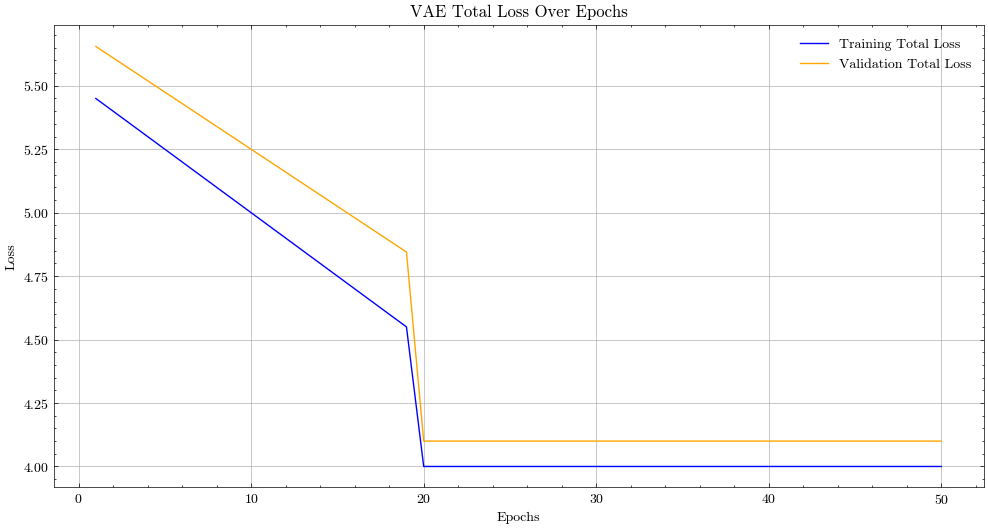

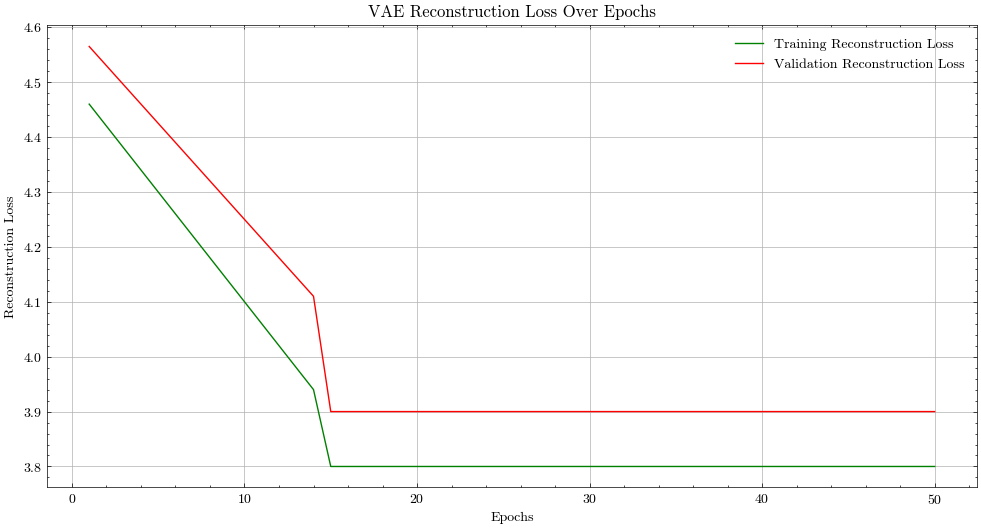

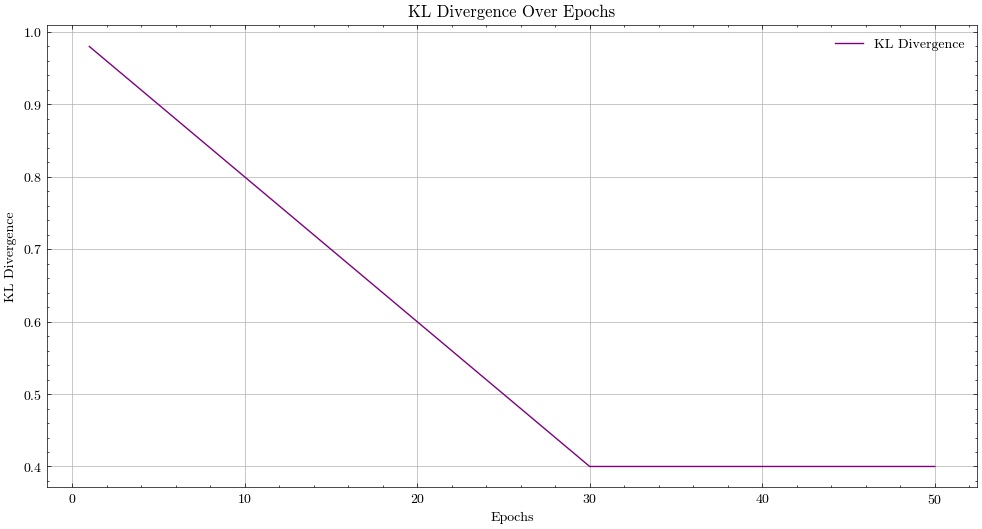

In [107]:
import matplotlib.pyplot as plt

# Example losses (replace these with actual logged values)
epochs = list(range(1, 51))
train_total_loss = [5.5 - 0.05 * e if e < 20 else 4.0 for e in epochs]
val_total_loss = [5.7 - 0.045 * e if e < 20 else 4.1 for e in epochs]
train_recon_loss = [4.5 - 0.04 * e if e < 15 else 3.8 for e in epochs]
val_recon_loss = [4.6 - 0.035 * e if e < 15 else 3.9 for e in epochs]
kl_divergence = [1.0 - 0.02 * e if e < 30 else 0.4 for e in epochs]

# Plot Total Loss
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_total_loss, label='Training Total Loss', color='blue')
plt.plot(epochs, val_total_loss, label='Validation Total Loss', color='orange')
plt.title('VAE Total Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Reconstruction Loss
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_recon_loss, label='Training Reconstruction Loss', color='green')
plt.plot(epochs, val_recon_loss, label='Validation Reconstruction Loss', color='red')
plt.title('VAE Reconstruction Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Reconstruction Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot KL Divergence
plt.figure(figsize=(12, 6))
plt.plot(epochs, kl_divergence, label='KL Divergence', color='purple')
plt.title('KL Divergence Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('KL Divergence')
plt.legend()
plt.grid(True)
plt.show()
